In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re

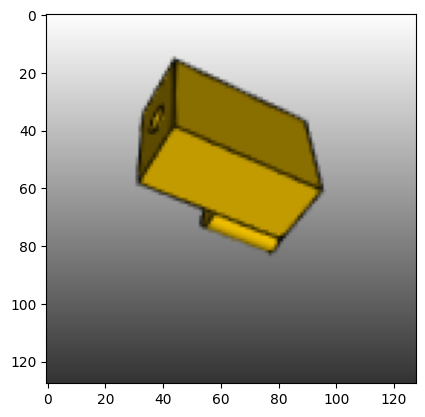

In [25]:
img = plt.imread("/home/brandonh/test_ar_dataset_7.png")
plt.imshow(img)

In [2]:
with open(
    "/home/brandonh/datasets/cad-recode-render-v1/train/01015_images.npy",
    "rb",
) as fp:
    images = np.load(fp)

In [3]:
images.shape

(1000, 8, 128, 128, 3)

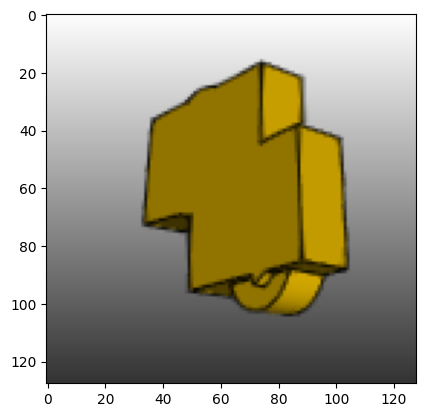

In [4]:
plt.imshow(images[0][0])

In [12]:
with open(
    "/home/brandonh/datasets/cad-recode-render-v1/train/32034_images.npy",
    "rb",
) as fp:
    images = np.load(fp)

In [14]:
images.shape

(1000, 8, 128, 128, 3)

In [16]:
with open(
    "/home/brandonh/datasets/cad-recode-render-v1/train/32034_cad_indices.npy",
    "rb",
) as fp:
    indices = np.load(fp)
indices.shape

(2000,)

In [8]:
!ls /home/brandonh/datasets/cad-recode-v1.5/train/batch_00

0.py	 200.py   2995.py  3993.py  4996.py  6.py     6996.py  8002.py	9005.py
1.py	 2000.py  2996.py  3994.py  4997.py  60.py    6997.py  8003.py	9006.py
10.py	 2001.py  2997.py  3995.py  4998.py  600.py   6998.py  8004.py	9007.py
100.py	 2002.py  2998.py  3996.py  4999.py  6000.py  6999.py  8005.py	9008.py
1000.py  2003.py  2999.py  3997.py  5.py     6001.py  7.py     8006.py	9009.py
1001.py  2004.py  3.py	   3998.py  50.py    6002.py  70.py    8007.py	901.py
1002.py  2005.py  30.py    3999.py  500.py   6003.py  700.py   8008.py	9010.py
1003.py  2006.py  300.py   4.py     5000.py  6004.py  7000.py  8009.py	9011.py
1004.py  2007.py  3000.py  40.py    5001.py  6005.py  7001.py  801.py	9012.py
1005.py  2008.py  3001.py  400.py   5002.py  6006.py  7002.py  8010.py	9013.py
1006.py  2009.py  3002.py  4000.py  5003.py  6007.py  7003.py  8011.py	9014.py
1007.py  201.py   3003.py  4001.py  5004.py  6008.py  7004.py  8012.py	9015.py
1008.py  2010.py  3004.py  4002.py  5005.py  6009.py  7005.py  8

In [20]:
with open("/home/vint/treecad-280/datasets/cad-recode-render-v1/train/01200.npy", "rb") as f:
    # Read the file content
    file_content = np.load(f, allow_pickle=True)

In [21]:
file_content.shape

(100, 8, 128, 128, 3)

In [23]:
len(os.listdir("/home/vint/treecad-280/datasets/cad-recode-v1.5/train/batch_00"))

9817

In [13]:
elevation_data.shape, roll_data.shape, image_data.shape

((1000, 8), (1000, 8), (1000, 8, 128, 128, 3))

In [7]:
data[0][0]

array([[[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[253, 253, 253],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]],

       [[251, 251, 251],
        [251, 251, 251],
        [251, 251, 251],
        ...,
        [251, 251, 251],
        [251, 251, 251],
        [251, 251, 251]],

       ...,

       [[ 55,  55,  55],
        [ 55,  55,  55],
        [ 55,  55,  55],
        ...,
        [ 55,  55,  55],
        [ 55,  55,  55],
        [ 55,  55,  55]],

       [[ 53,  53,  53],
        [ 53,  53,  53],
        [ 53,  53,  53],
        ...,
        [ 53,  53,  53],
        [ 53,  53,  53],
        [ 53,  53,  53]],

       [[ 52,  52,  52],
        [ 52,  52,  52],
        [ 52,  52,  52],
        ...,
        [ 52,  52,  52],
        [ 52,  52,  52],
        [ 52,  52,  52]]

In [18]:
regex_pattern = r"266-img_r(?P<roll>-?\d+)_e(?P<elevation>-?\d+).png"
def extract_roll_elevation(filename):
    match = re.search(regex_pattern, filename)
    if match:
        roll = int(match.group(1))
        elevation = int(match.group(2))
        return roll, elevation
    else:
        raise ValueError(f"Filename {filename} does not match the expected pattern.")

In [21]:
all_images = os.listdir('../img_debug')
img_re_mapping = {
    extract_roll_elevation(img): img for img in all_images
}

In [25]:
all_rolls = set(sorted([k[0] for k in img_re_mapping]))
all_elevations = set(sorted([k[1] for k in img_re_mapping]))

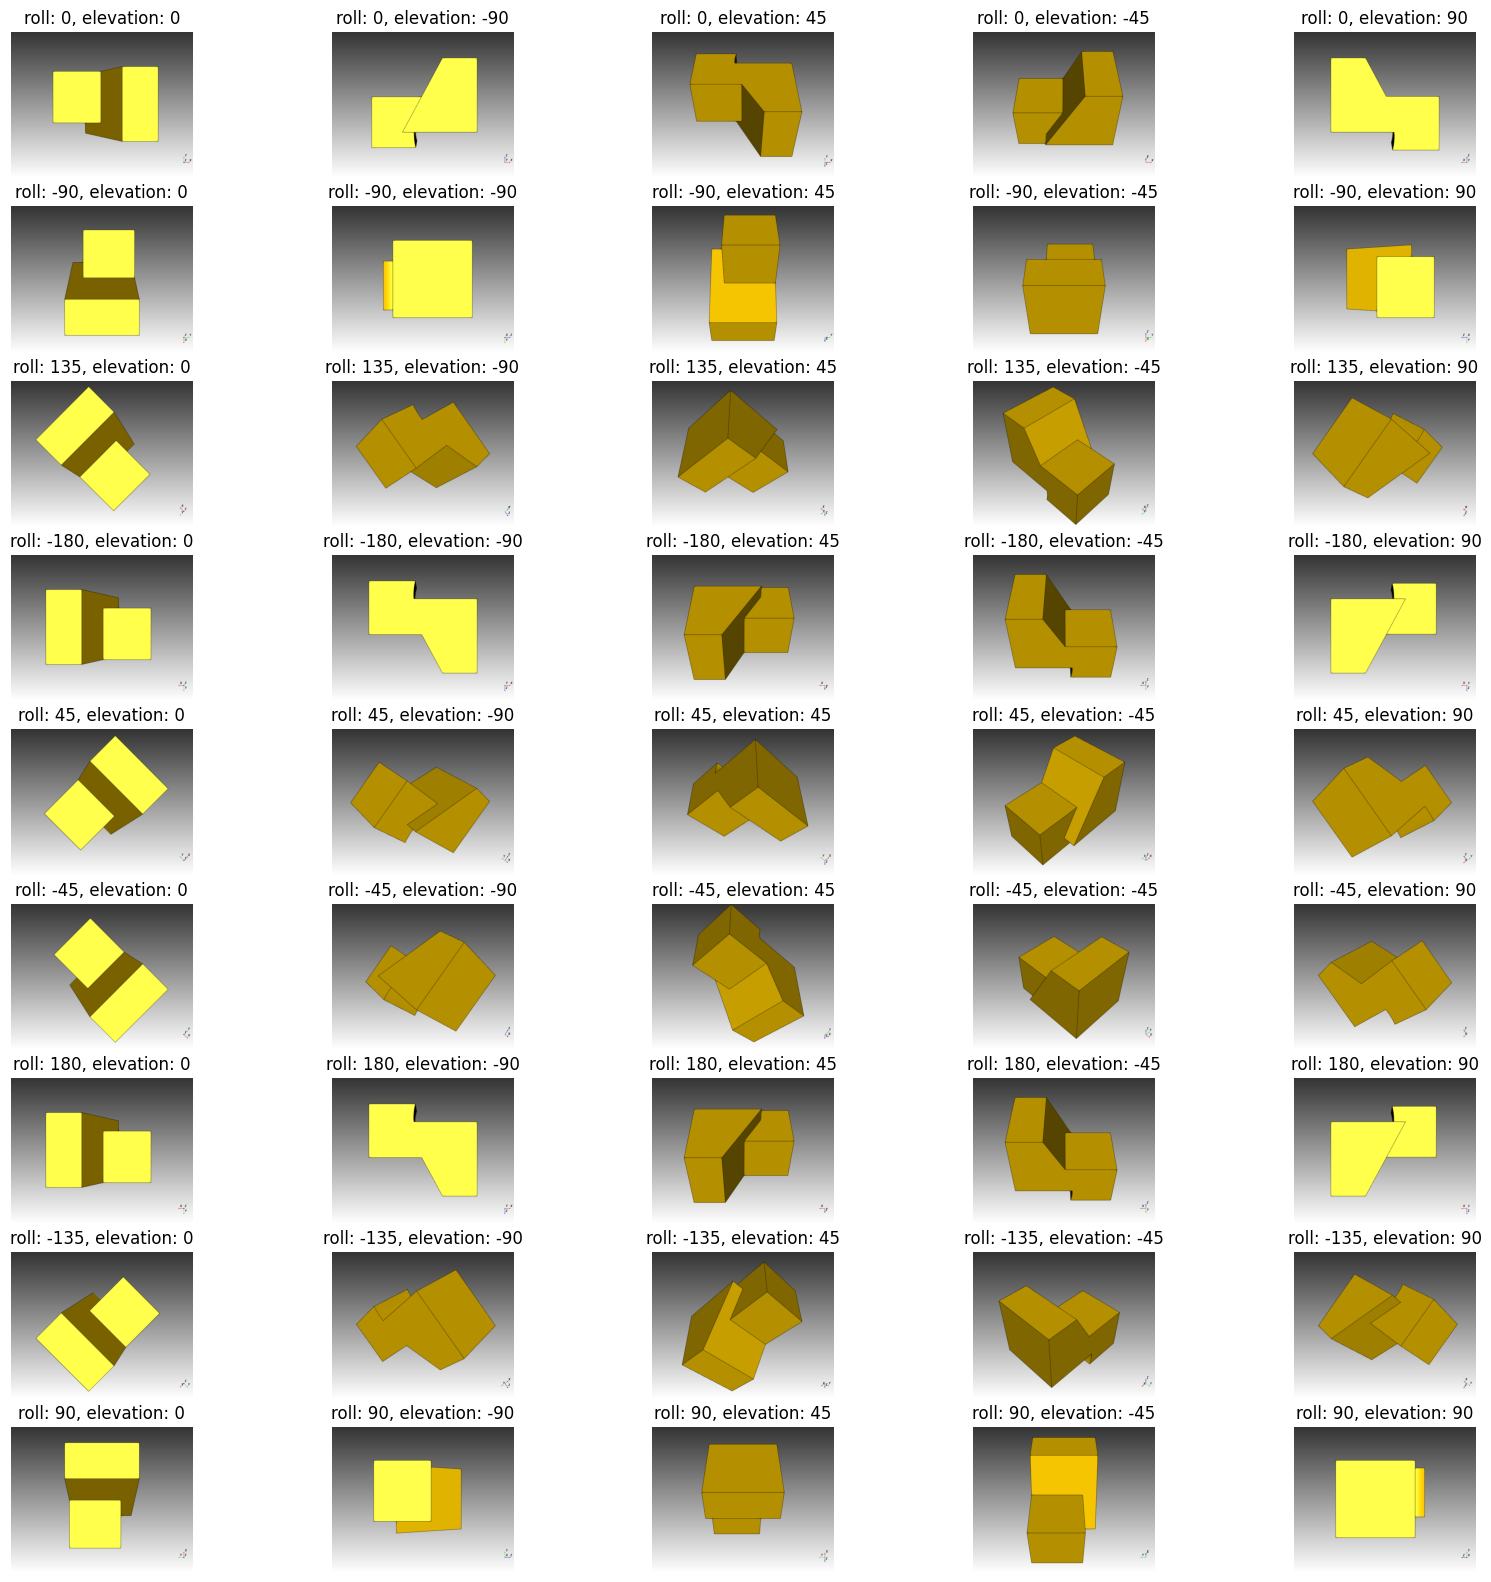

In [28]:
figs, axes = plt.subplots(len(all_rolls), len(all_elevations), figsize=(20, 20))
for i, roll in enumerate(all_rolls):
    for j, elevation in enumerate(all_elevations):
        ax = axes[i, j]
        ax.set_title(f"roll: {roll}, elevation: {elevation}")
        ax.axis('off')
        img_key = (roll, elevation)
        if img_key in img_re_mapping:
            img_path = os.path.join('../img_debug', img_re_mapping[img_key])
            img = plt.imread(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "No Image", fontsize=12, ha='center', va='center')  # Placeholder for missing images